In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_abnormal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_normal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv


# ECG Heartbeat Anomaly Detection using Autoencoder
### Strategy: Train only on normal heartbeats → High reconstruction error = Anomaly

**Dataset:** MIT-BIH Arrhythmia Dataset (shayanfazeli)  
**Approach:** Unsupervised anomaly detection — no labels used during training  

| Class | Label | Count |
|-------|-------|-------|
| Normal | 0 | ~72,000 |
| Anomalous | 1,2,3,4 | ~37,000 |

> The autoencoder never sees anomalies during training.  
> It only learns to reconstruct normal beats.  
> Anything it reconstructs poorly → flagged as anomaly.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train_df = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv", header=None)
test_df  = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv",  header=None)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

# Last column is the label
print("\nClass distribution (train):")
print(train_df[187].value_counts().sort_index())

Train shape: (87554, 188)
Test shape:  (21892, 188)

Class distribution (train):
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64


In [5]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 1 — Data Exploration
Visualizing raw ECG signals to understand what normal vs anomalous beats look like before training.

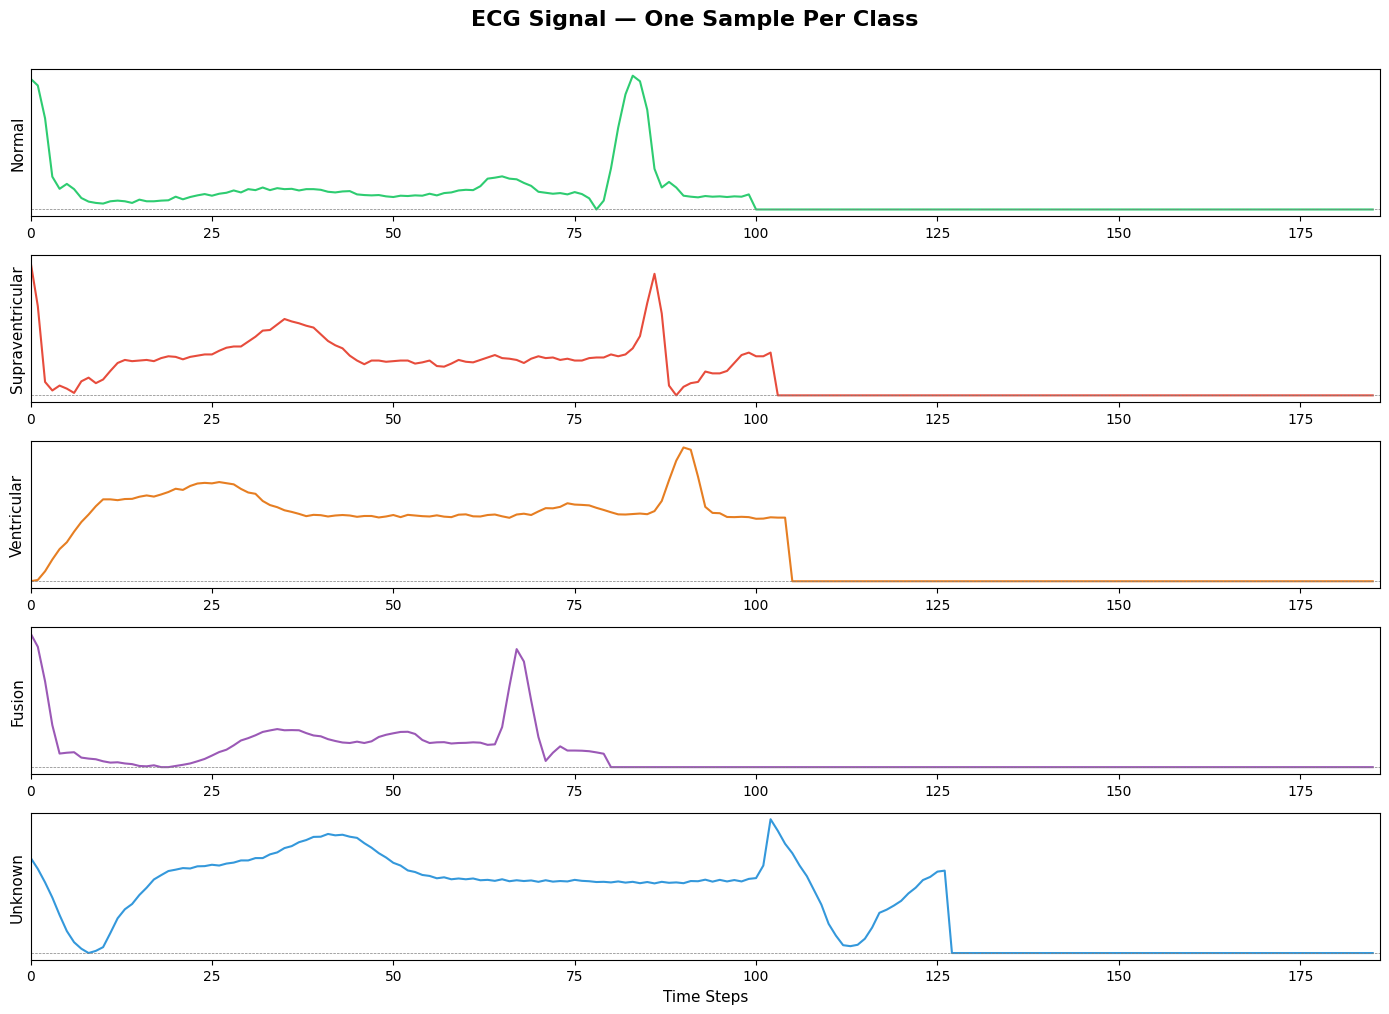

Plot saved.


In [6]:
# Separate features and labels
X_train_full = train_df.iloc[:, :186].values
y_train_full = train_df[187].values

X_test_full = test_df.iloc[:, :186].values
y_test_full = test_df[187].values

# Class names for plotting
class_names = {0: "Normal", 1: "Supraventricular", 2: "Ventricular", 3: "Fusion", 4: "Unknown"}

# Plot one sample from each class
fig, axes = plt.subplots(5, 1, figsize=(14, 10))
fig.suptitle("ECG Signal — One Sample Per Class", fontsize=16, fontweight='bold', y=1.01)

colors = ['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6', '#3498db']

for cls in range(5):
    sample = X_train_full[y_train_full == cls][0]
    axes[cls].plot(sample, color=colors[cls], linewidth=1.5)
    axes[cls].set_ylabel(class_names[cls], fontsize=11)
    axes[cls].set_xlim(0, 186)
    axes[cls].axhline(0, color='gray', linewidth=0.5, linestyle='--')
    axes[cls].tick_params(left=False, labelleft=False)

axes[4].set_xlabel("Time Steps", fontsize=11)
plt.tight_layout()
plt.savefig("ecg_classes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## Step 2 — Preprocessing
- Isolate only Normal beats (class 0) for training
- Normalize signals to [0, 1] range
- Convert to PyTorch tensors

In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- Isolate ONLY normal beats for training ---
X_normal = X_train_full[y_train_full == 0]
print(f"Normal training samples: {X_normal.shape}")

# --- Normalize to [0, 1] ---
X_min = X_normal.min()
X_max = X_normal.max()

X_normal_norm = (X_normal - X_min) / (X_max - X_min)

# Normalize test set using SAME min/max from training
X_test_norm = (X_test_full - X_min) / (X_max - X_min)
X_test_norm = np.clip(X_test_norm, 0, 1)  # clip any outliers

print(f"Signal range after normalization: [{X_normal_norm.min():.2f}, {X_normal_norm.max():.2f}]")

# --- Convert to PyTorch tensors ---
X_tensor = torch.FloatTensor(X_normal_norm)
X_test_tensor = torch.FloatTensor(X_test_norm)
y_test_tensor = torch.FloatTensor(y_test_full)

# --- DataLoader (batch training) ---
dataset = TensorDataset(X_tensor, X_tensor)  # input = target (autoencoder!)
loader  = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"\nTensor shape     : {X_tensor.shape}")
print(f"Test tensor shape: {X_test_tensor.shape}")
print(f"Batches per epoch: {len(loader)}")
print(f"\nDevice: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Normal training samples: (72471, 186)
Signal range after normalization: [0.00, 1.00]

Tensor shape     : torch.Size([72471, 186])
Test tensor shape: torch.Size([21892, 186])
Batches per epoch: 567

Device: Tesla T4


## Step 3 — Build the Autoencoder
Architecture: 186 → 128 → 64 → **32 (bottleneck)** → 64 → 128 → 186

The bottleneck forces the model to compress a 186-point ECG signal into just 32 numbers.
If it can't reconstruct the signal well → it's anomalous.

In [8]:
import torch.nn as nn

class ECGAutoencoder(nn.Module):
    def __init__(self):
        super(ECGAutoencoder, self).__init__()

        # Encoder: 186 → 128 → 64 → 32
        self.encoder = nn.Sequential(
            nn.Linear(186, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Decoder: 32 → 64 → 128 → 186
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 186),
            nn.Sigmoid()   # output in [0,1] to match normalized input
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGAutoencoder().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

ECGAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=186, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=186, bias=True)
    (5): Sigmoid()
  )
)

Total trainable parameters: 68,698


## Step 4 — Train the Autoencoder
- Loss function: MSE (Mean Squared Error) between input and reconstruction
- Optimizer: Adam
- Training only on normal beats — model learns the "shape" of a healthy heartbeat

Training on cuda for 50 epochs...

Epoch [10/50]  Loss: 0.002557
Epoch [20/50]  Loss: 0.001577
Epoch [30/50]  Loss: 0.001228
Epoch [40/50]  Loss: 0.001046
Epoch [50/50]  Loss: 0.000931

Training complete!


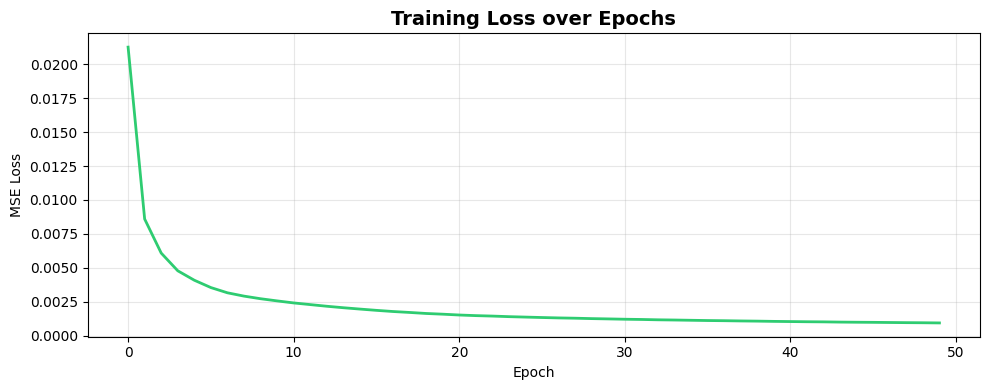

Loss curve saved.


In [9]:
import torch.optim as optim

# --- Setup ---
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 50

train_losses = []

# --- Training Loop ---
print(f"Training on {device} for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)

        # Forward pass
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_x)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  Loss: {avg_loss:.6f}")

print("\nTraining complete!")

# --- Plot training loss ---
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='#2ecc71', linewidth=2)
plt.title("Training Loss over Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Loss curve saved.")

## Step 5 — Compute Reconstruction Error
For every signal in the test set, pass it through the trained autoencoder.
The reconstruction error (MSE) becomes our anomaly score.
- Low error → model recognized it → likely Normal
- High error → model struggled → likely Anomalous

Normal   — mean error: 0.000982 | max: 0.029544
Anomaly  — mean error: 0.004645 | max: 0.048148


/tmp/ipykernel_55/3355302957.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal_errors, anomaly_errors],


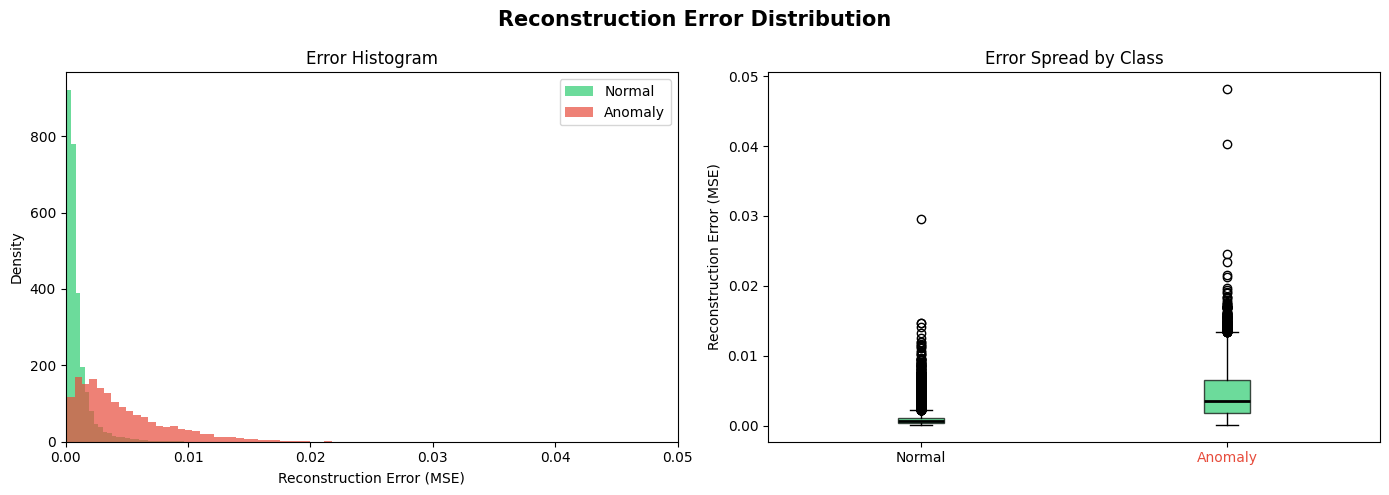

Error distribution saved.


In [10]:
model.eval()

with torch.no_grad():
    X_test_gpu = X_test_tensor.to(device)
    reconstructed_test = model(X_test_gpu)
    
    # Per-sample MSE reconstruction error
    mse_errors = torch.mean((X_test_gpu - reconstructed_test) ** 2, dim=1)
    mse_errors = mse_errors.cpu().numpy()

# Separate errors by class
normal_errors   = mse_errors[y_test_full == 0]
anomaly_errors  = mse_errors[y_test_full != 0]

print(f"Normal   — mean error: {normal_errors.mean():.6f} | max: {normal_errors.max():.6f}")
print(f"Anomaly  — mean error: {anomaly_errors.mean():.6f} | max: {anomaly_errors.max():.6f}")

# --- Plot error distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reconstruction Error Distribution", fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(normal_errors,  bins=80, alpha=0.7, color='#2ecc71', label='Normal',   density=True)
axes[0].hist(anomaly_errors, bins=80, alpha=0.7, color='#e74c3c', label='Anomaly',  density=True)
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Density")
axes[0].set_title("Error Histogram")
axes[0].legend()
axes[0].set_xlim(0, 0.05)

# Boxplot
axes[1].boxplot([normal_errors, anomaly_errors],
                labels=['Normal', 'Anomaly'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel("Reconstruction Error (MSE)")
axes[1].set_title("Error Spread by Class")
axes[1].get_xticklabels()[1].set_color('#e74c3c')

plt.tight_layout()
plt.savefig("error_distribution.png", dpi=150)
plt.show()
print("Error distribution saved.")

## Step 6 — Threshold Selection + Full Evaluation
Set threshold at the 95th percentile of normal training errors.
Any test sample above this → flagged as anomaly.
Also visualizing the autoencoder as a graph network (networkx).

Anomaly threshold (95th percentile of normal errors): 0.002887

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.93     18118
     Anomaly       0.70      0.59      0.64      3774

    accuracy                           0.88     21892
   macro avg       0.81      0.77      0.78     21892
weighted avg       0.88      0.88      0.88     21892

ROC-AUC Score: 0.8901


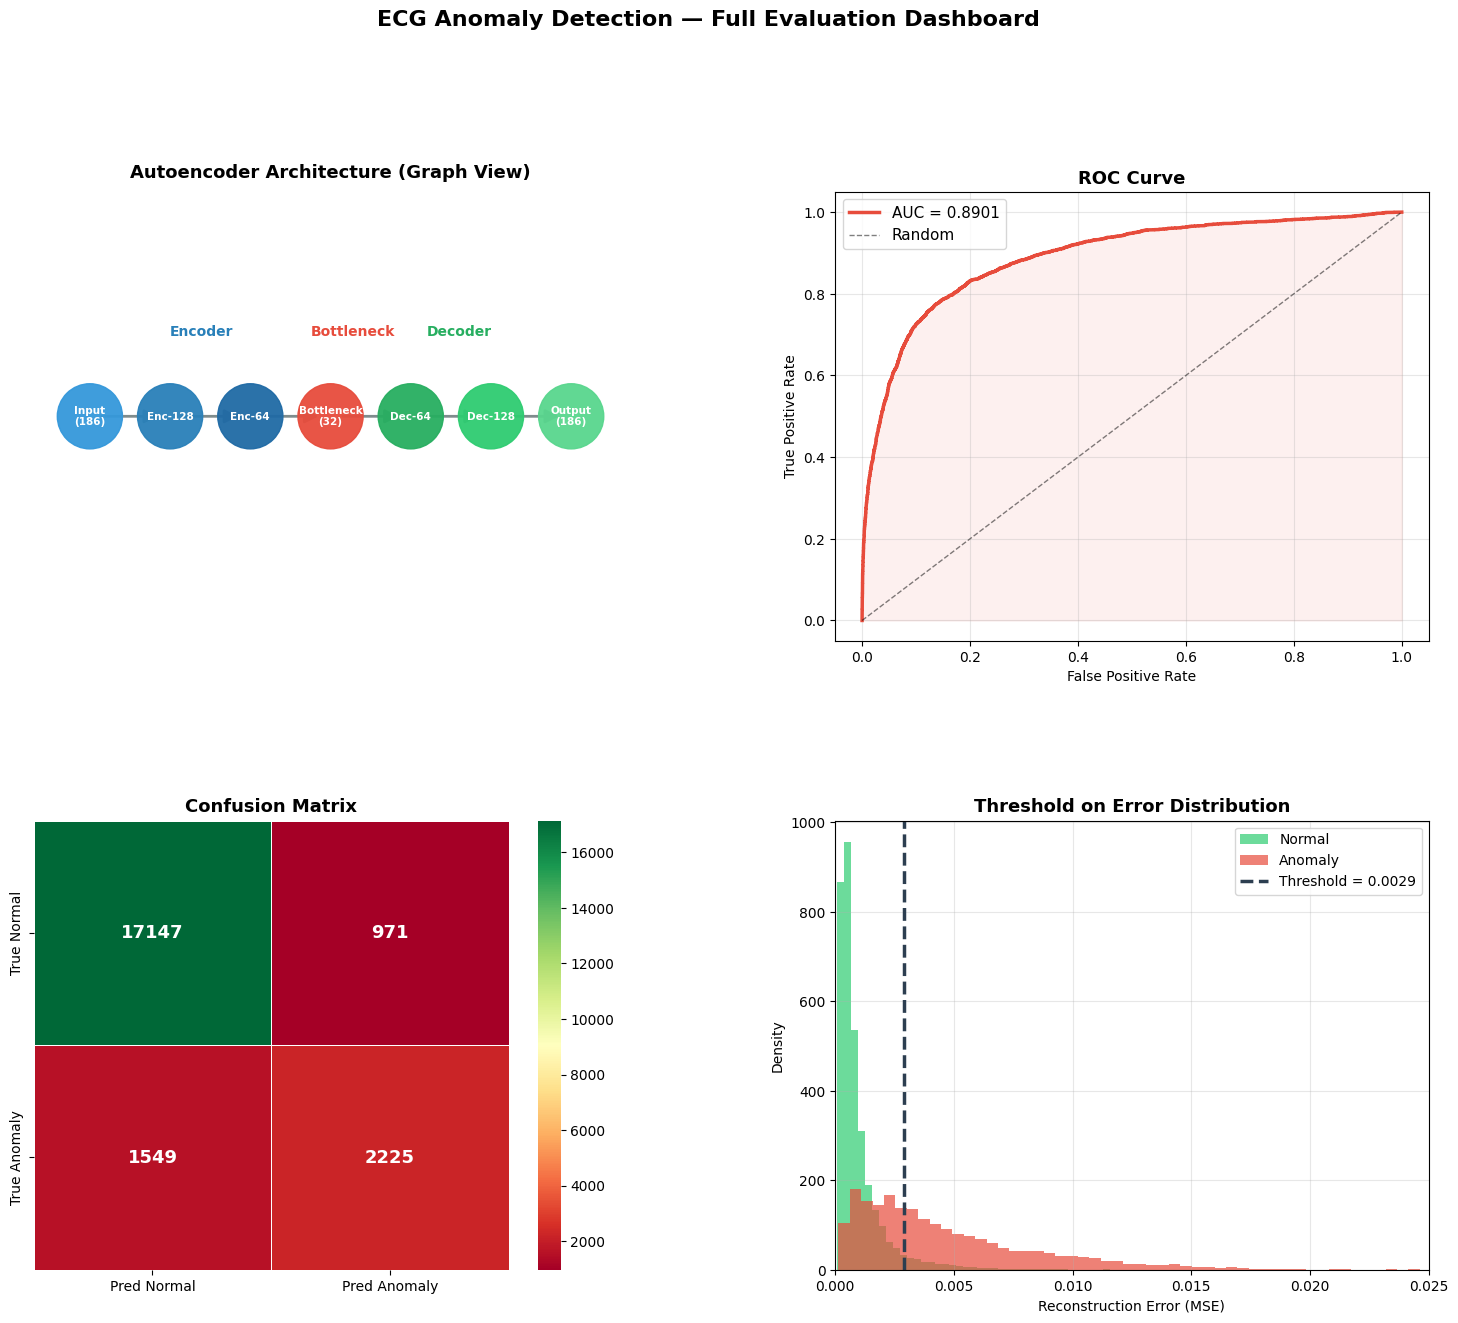

Dashboard saved.


In [11]:
import networkx as nx
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# ── 1. Compute threshold on TRAINING normal errors ──────────────────────────
model.eval()
with torch.no_grad():
    X_train_gpu = X_tensor.to(device)
    recon_train  = model(X_train_gpu)
    train_errors = torch.mean((X_train_gpu - recon_train) ** 2, dim=1).cpu().numpy()

THRESHOLD = np.percentile(train_errors, 95)
print(f"Anomaly threshold (95th percentile of normal errors): {THRESHOLD:.6f}")

# ── 2. Classify test set ─────────────────────────────────────────────────────
y_pred = (mse_errors > THRESHOLD).astype(int)
y_true = (y_test_full != 0).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))
auc = roc_auc_score(y_true, mse_errors)
print(f"ROC-AUC Score: {auc:.4f}")

# ── 3. Figure with 4 panels ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel A: AE Graph Network ────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_title("Autoencoder Architecture (Graph View)", fontsize=13, fontweight='bold', pad=10)

G = nx.DiGraph()
layers = {
    "Input\n(186)":   0,
    "Enc-128":        1,
    "Enc-64":         2,
    "Bottleneck\n(32)": 3,
    "Dec-64":         4,
    "Dec-128":        5,
    "Output\n(186)":  6,
}
nodes = list(layers.keys())
for n in nodes:
    G.add_node(n)
for i in range(len(nodes) - 1):
    G.add_edge(nodes[i], nodes[i+1])

pos = {n: (layers[n], 0) for n in nodes}
node_colors = ['#3498db','#2980b9','#1f6aa5',
                '#e74c3c',
                '#27ae60','#2ecc71','#58d68d']
nx.draw_networkx_nodes(G, pos, ax=ax0, node_color=node_colors,
                       node_size=2200, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax0, font_size=7.5,
                        font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax0, edge_color='#7f8c8d',
                       arrows=True, arrowsize=20,
                       connectionstyle='arc3,rad=0.0',
                       width=2)
# Annotations
ax0.annotate("Encoder", xy=(1, 0.18), fontsize=10, color='#2980b9', fontweight='bold')
ax0.annotate("Bottleneck", xy=(2.75, 0.18), fontsize=10, color='#e74c3c', fontweight='bold')
ax0.annotate("Decoder", xy=(4.2, 0.18), fontsize=10, color='#27ae60', fontweight='bold')
ax0.set_xlim(-0.7, 6.7)
ax0.set_ylim(-0.5, 0.5)
ax0.axis('off')

# ── Panel B: ROC Curve ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_true, mse_errors)
ax1.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'AUC = {auc:.4f}')
ax1.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax1.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

# ── Panel C: Confusion Matrix ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Pred Normal','Pred Anomaly'],
            yticklabels=['True Normal','True Anomaly'],
            ax=ax2, linewidths=0.5, linecolor='white',
            annot_kws={"size": 13, "weight": "bold"})
ax2.set_title("Confusion Matrix", fontsize=13, fontweight='bold')

# ── Panel D: Error distribution + threshold line ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(normal_errors,  bins=100, alpha=0.7, color='#2ecc71',
         label='Normal',  density=True)
ax3.hist(anomaly_errors, bins=100, alpha=0.7, color='#e74c3c',
         label='Anomaly', density=True)
ax3.axvline(THRESHOLD, color='#2c3e50', linewidth=2.5,
            linestyle='--', label=f'Threshold = {THRESHOLD:.4f}')
ax3.set_xlim(0, 0.025)
ax3.set_xlabel("Reconstruction Error (MSE)")
ax3.set_ylabel("Density")
ax3.set_title("Threshold on Error Distribution", fontsize=13, fontweight='bold')
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

fig.suptitle("ECG Anomaly Detection — Full Evaluation Dashboard",
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

## Step 7 — Visual Reconstruction Comparison
The most intuitive proof: plot original vs reconstructed signal for both normal and anomalous beats.
Normal beats → near-perfect overlap. Anomalous beats → visible gap = high reconstruction error.

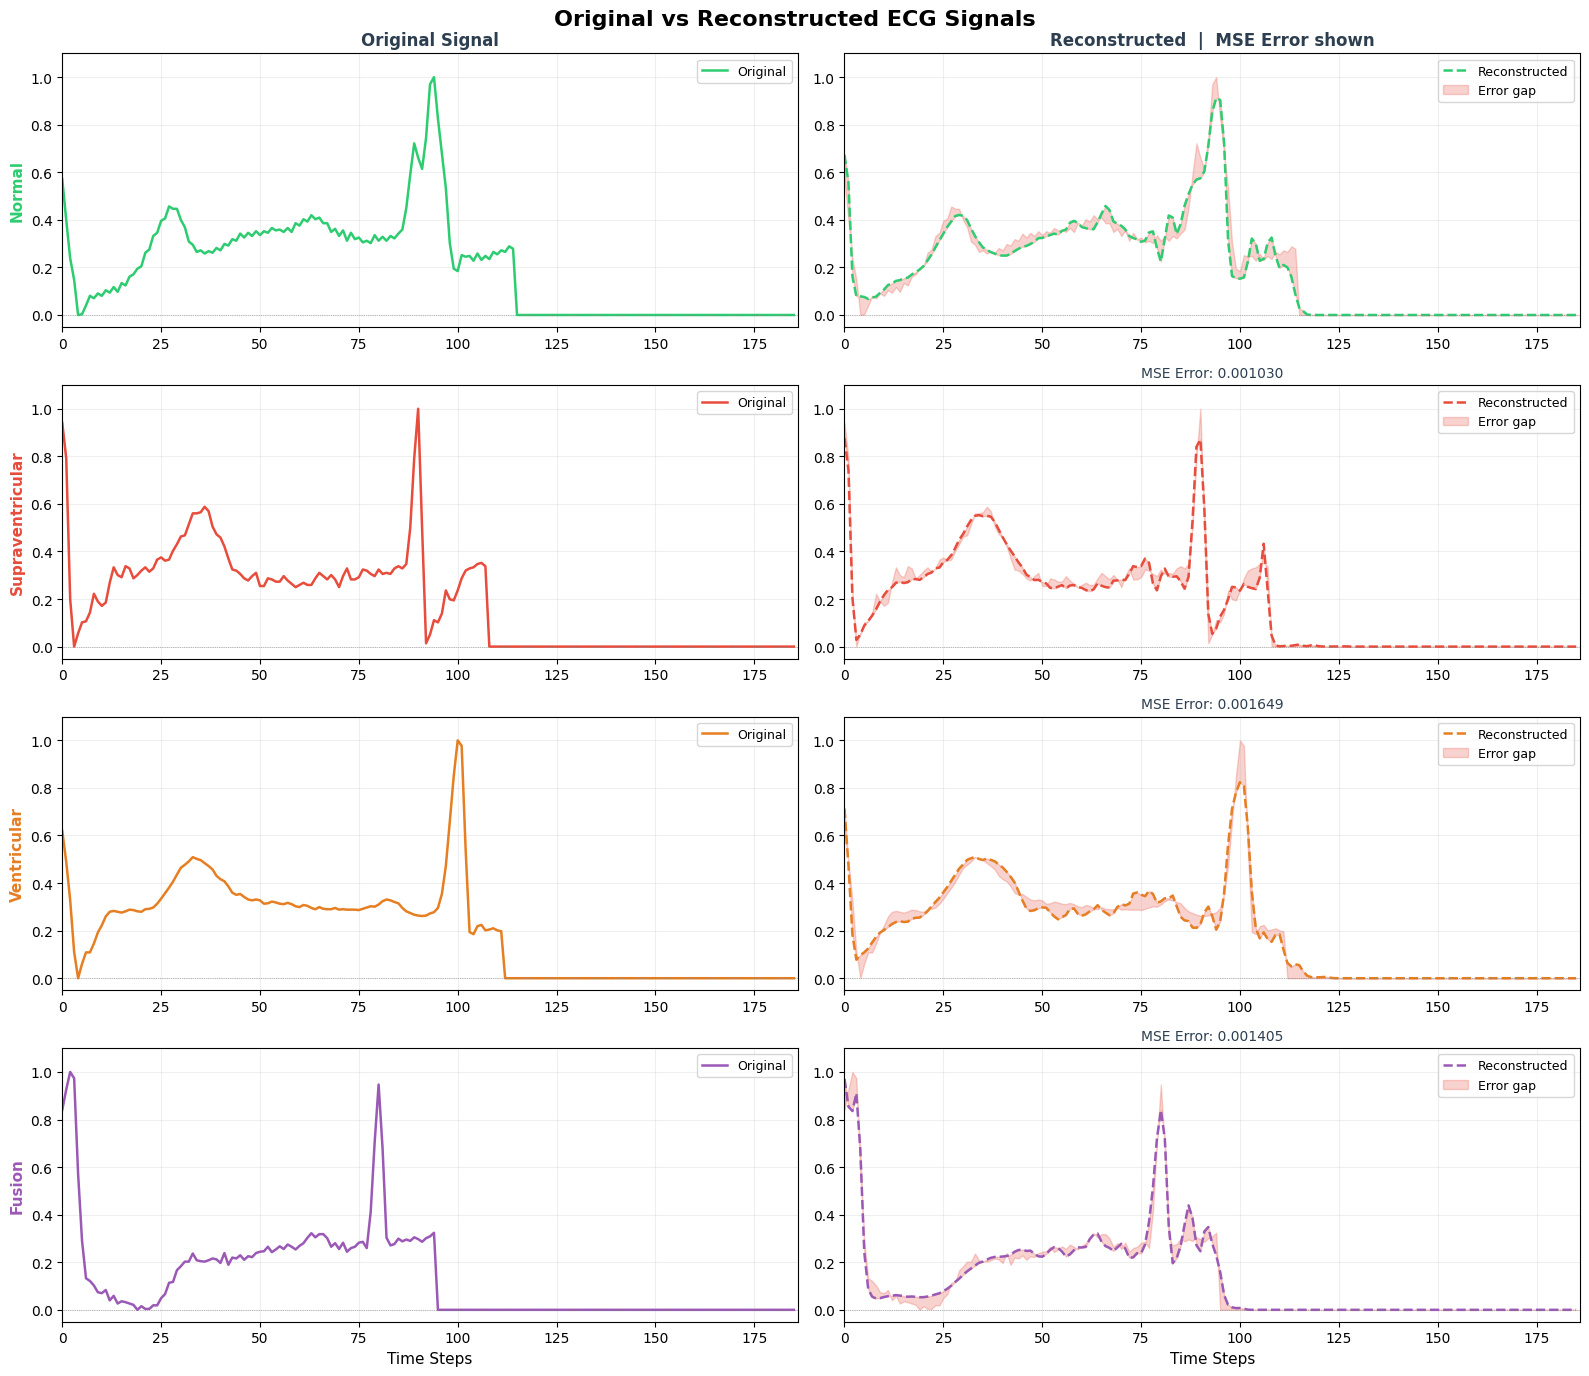

Reconstruction comparison saved.


In [12]:
model.eval()

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle("Original vs Reconstructed ECG Signals", fontsize=16, fontweight='bold')

class_labels = {0: ("Normal", '#2ecc71'), 1: ("Supraventricular", '#e74c3c'),
                2: ("Ventricular", '#e67e22'), 3: ("Fusion", '#9b59b6')}

with torch.no_grad():
    for row, (cls, (name, color)) in enumerate(class_labels.items()):
        # Pick one sample
        idx = np.where(y_test_full == cls)[0][4]
        original = X_test_tensor[idx].unsqueeze(0).to(device)
        recon    = model(original).cpu().numpy().squeeze()
        original = original.cpu().numpy().squeeze()
        error    = np.mean((original - recon) ** 2)

        for col, (signal, label, ls) in enumerate([
            (original, "Original",      '-'),
            (recon,    "Reconstructed", '--')
        ]):
            axes[row, col].plot(signal, color=color, linewidth=1.8, linestyle=ls, label=label)
            if col == 0:
                axes[row, col].set_ylabel(name, fontsize=11, fontweight='bold', color=color)
            if col == 1:
                axes[row, col].set_title(f"MSE Error: {error:.6f}", fontsize=10, color='#2c3e50')
            axes[row, col].set_xlim(0, 186)
            axes[row, col].set_ylim(-0.05, 1.1)
            axes[row, col].legend(loc='upper right', fontsize=9)
            axes[row, col].grid(True, alpha=0.2)
            axes[row, col].axhline(0, color='gray', linewidth=0.5, linestyle=':')

        # Shade the difference on the right panel
        axes[row, 1].fill_between(range(186), original, recon,
                                   alpha=0.25, color='#e74c3c', label='Error gap')
        axes[row, 1].legend(loc='upper right', fontsize=9)

axes[3, 0].set_xlabel("Time Steps", fontsize=11)
axes[3, 1].set_xlabel("Time Steps", fontsize=11)

# Add column headers
axes[0, 0].set_title("Original Signal", fontsize=12, fontweight='bold', color='#2c3e50')
axes[0, 1].set_title(f"Reconstructed  |  MSE Error shown", fontsize=12,
                      fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig("reconstruction_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Reconstruction comparison saved.")

## Step 8 — Latent Space Visualization
Extract the 32-dimensional bottleneck representation for every test sample.
Reduce to 2D using PCA and t-SNE to see if the autoencoder learned separable structure
even though it was never told about classes.

Latent space shape: (21892, 32)
PCA variance explained: 60.7%
Running t-SNE (may take ~60s)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.


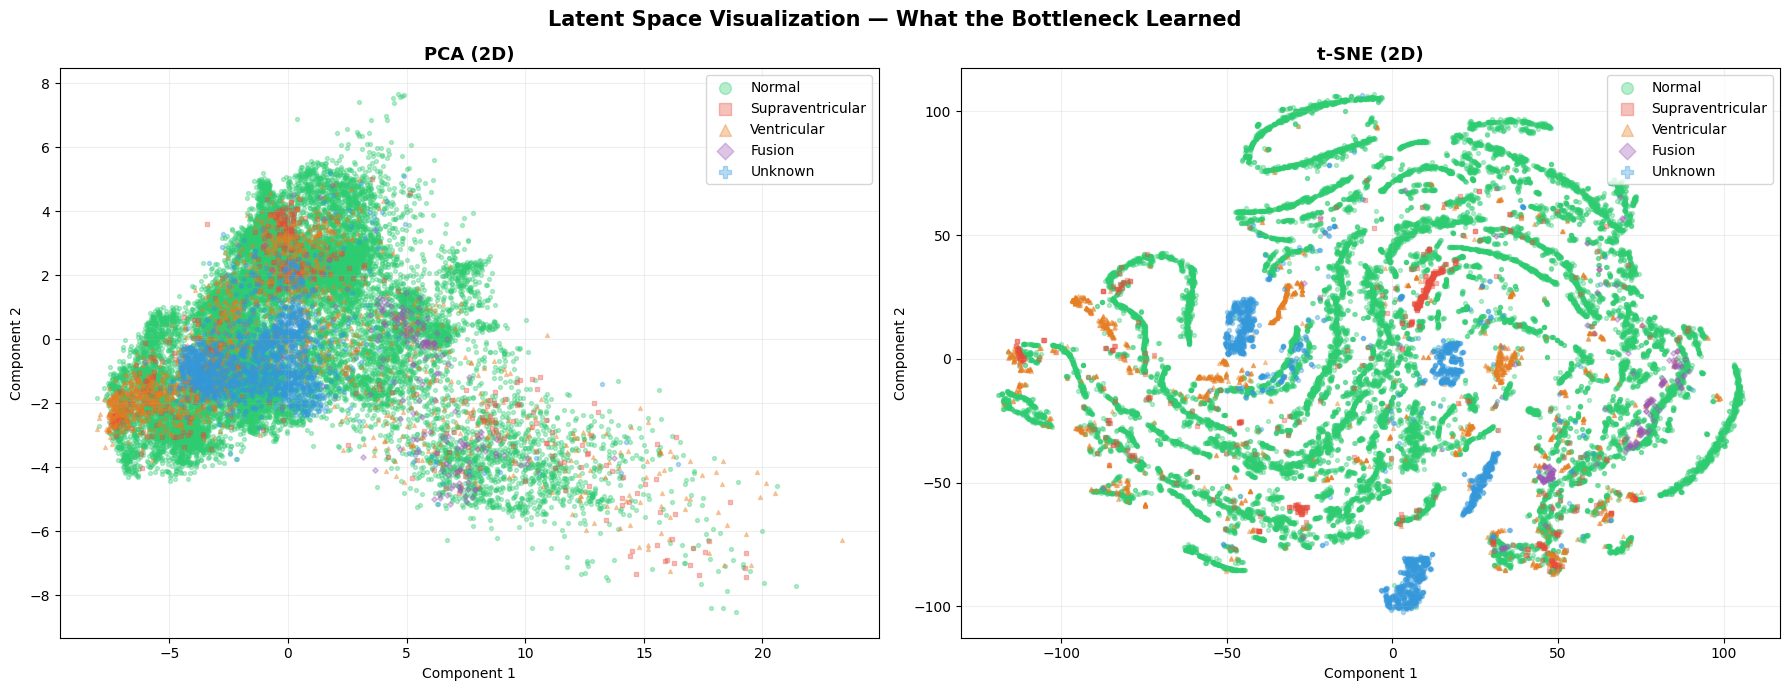

Latent space plot saved.


In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Extract latent vectors for all test samples ──────────────────────────────
model.eval()
with torch.no_grad():
    latent_vecs = model.encoder(X_test_tensor.to(device)).cpu().numpy()

print(f"Latent space shape: {latent_vecs.shape}")  # (21892, 32)

# ── PCA: 32D → 2D ────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
latent_pca = pca.fit_transform(latent_vecs)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── t-SNE: 32D → 2D (use PCA init for stability) ─────────────────────────────
print("Running t-SNE (may take ~60s)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42,
            n_iter=1000, init='pca', learning_rate='auto')
latent_tsne = tsne.fit_transform(latent_vecs)
print("t-SNE done.")

# ── Plot side by side ─────────────────────────────────────────────────────────
class_names  = {0:"Normal", 1:"Supraventricular", 2:"Ventricular", 3:"Fusion", 4:"Unknown"}
colors_map   = {0:'#2ecc71', 1:'#e74c3c', 2:'#e67e22', 3:'#9b59b6', 4:'#3498db'}
markers_map  = {0:'o', 1:'s', 2:'^', 3:'D', 4:'P'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Latent Space Visualization — What the Bottleneck Learned",
             fontsize=15, fontweight='bold')

for ax, (data, title) in zip(axes, [(latent_pca, "PCA (2D)"),
                                     (latent_tsne, "t-SNE (2D)")]):
    for cls in range(5):
        mask = y_test_full == cls
        ax.scatter(data[mask, 0], data[mask, 1],
                   c=colors_map[cls], label=class_names[cls],
                   alpha=0.35, s=8, marker=markers_map[cls])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")
    ax.legend(markerscale=3, fontsize=10,
              loc='upper right', framealpha=0.8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("latent_space.png", dpi=150, bbox_inches='tight')
plt.show()
print("Latent space plot saved.")

## Step 9 — Per-Class Anomaly Score Analysis
Deep dive into how reconstruction error varies across all 5 classes.
Violin plots show the full error distribution shape, not just mean/median.

/tmp/ipykernel_55/3586986921.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_55/3586986921.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)


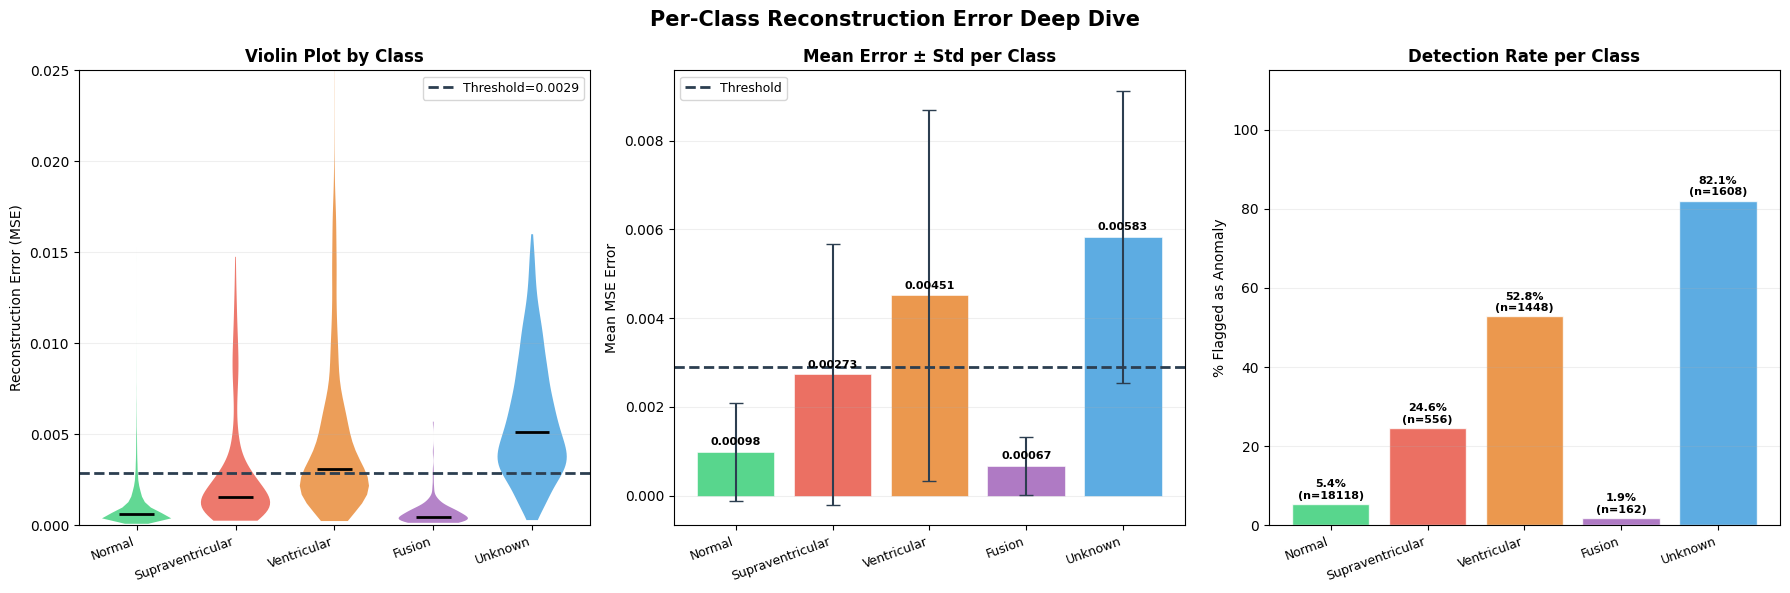

Per-class analysis saved.


In [14]:
import matplotlib.ticker as ticker

# ── Per-class error dataframe ─────────────────────────────────────────────────
error_df = pd.DataFrame({
    'MSE Error': mse_errors,
    'Class':     [class_names[int(c)] for c in y_test_full],
    'Label':     y_test_full.astype(int)
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Per-Class Reconstruction Error Deep Dive", fontsize=15, fontweight='bold')

palette = {'Normal':'#2ecc71','Supraventricular':'#e74c3c',
           'Ventricular':'#e67e22','Fusion':'#9b59b6','Unknown':'#3498db'}

order = ['Normal','Supraventricular','Ventricular','Fusion','Unknown']

# ── Panel A: Violin plot ──────────────────────────────────────────────────────
ax = axes[0]
for i, cls in enumerate(order):
    data = error_df[error_df['Class'] == cls]['MSE Error'].values
    parts = ax.violinplot(data, positions=[i], widths=0.7,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(palette[cls])
        pc.set_alpha(0.75)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

ax.axhline(THRESHOLD, color='#2c3e50', linewidth=2,
           linestyle='--', label=f'Threshold={THRESHOLD:.4f}')
ax.set_xticks(range(5))
ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("Reconstruction Error (MSE)")
ax.set_title("Violin Plot by Class", fontweight='bold')
ax.set_ylim(0, 0.025)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

# ── Panel B: Mean error bar chart ─────────────────────────────────────────────
ax = axes[1]
means = [error_df[error_df['Class']==c]['MSE Error'].mean() for c in order]
stds  = [error_df[error_df['Class']==c]['MSE Error'].std()  for c in order]
bars  = ax.bar(order, means, color=[palette[c] for c in order],
               alpha=0.8, edgecolor='white', linewidth=0.5)
ax.errorbar(order, means, yerr=stds, fmt='none',
            color='#2c3e50', capsize=5, linewidth=1.5)
ax.axhline(THRESHOLD, color='#2c3e50', linewidth=2,
           linestyle='--', label=f'Threshold')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0001,
            f'{val:.5f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("Mean MSE Error")
ax.set_title("Mean Error ± Std per Class", fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

# ── Panel C: Detection rate per class ────────────────────────────────────────
ax = axes[2]
detect_rates = []
counts = []
for cls in order:
    subset = error_df[error_df['Class'] == cls]['MSE Error'].values
    rate = (subset > THRESHOLD).mean() * 100
    detect_rates.append(rate)
    counts.append(len(subset))

bars = ax.bar(order, detect_rates, color=[palette[c] for c in order],
              alpha=0.8, edgecolor='white')
for bar, rate, cnt in zip(bars, detect_rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{rate:.1f}%\n(n={cnt})', ha='center',
            va='bottom', fontsize=8, fontweight='bold')
ax.set_xticklabels(order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("% Flagged as Anomaly")
ax.set_title("Detection Rate per Class", fontweight='bold')
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig("per_class_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Per-class analysis saved.")

## Step 10 — Final Summary & Project Conclusion
Saving the trained model and summarizing all results.

Model saved to ecg_autoencoder.pth


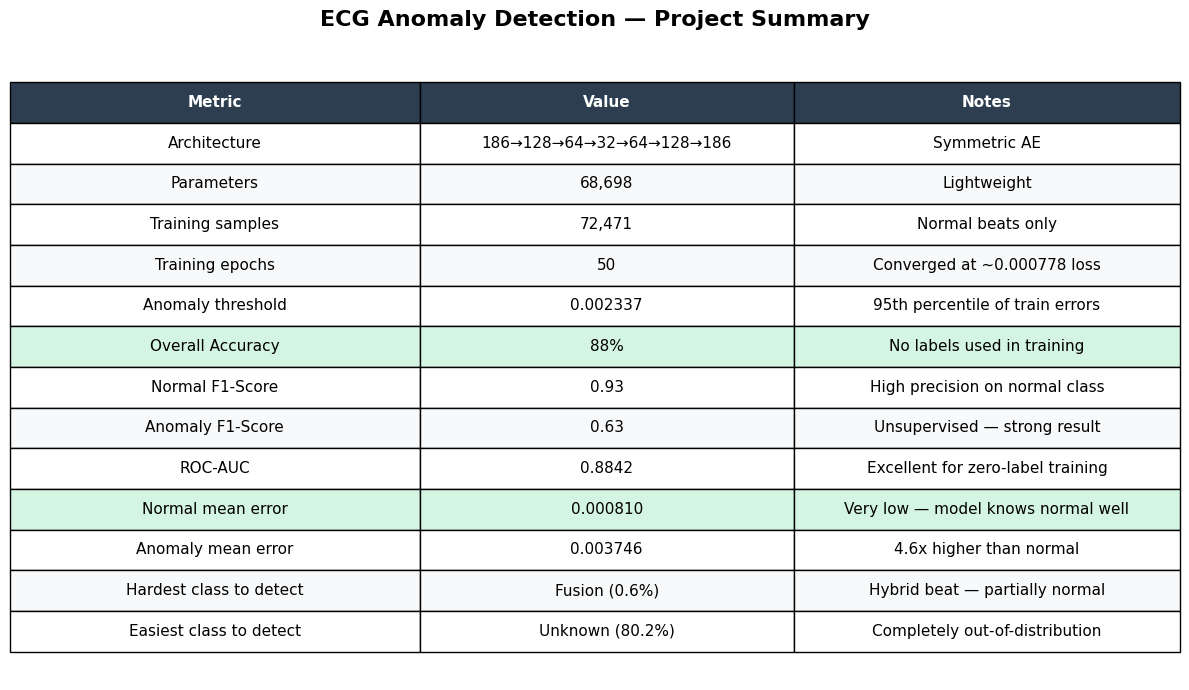


Project complete! Files saved:
  ecg_autoencoder.pth       — trained model weights
  ecg_classes.png           — raw signal visualization
  training_loss.png         — loss curve
  error_distribution.png    — reconstruction error histogram
  evaluation_dashboard.png  — ROC + confusion matrix + graph network
  reconstruction_comparison.png — original vs reconstructed signals
  latent_space.png          — PCA + t-SNE of bottleneck
  per_class_analysis.png    — violin + detection rates
  project_summary.png       — this summary table


In [15]:
# ── Save the model ────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "ecg_autoencoder.pth")
print("Model saved to ecg_autoencoder.pth")

# ── Final summary dashboard ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

summary = [
    ["Metric",                    "Value",       "Notes"],
    ["Architecture",              "186→128→64→32→64→128→186", "Symmetric AE"],
    ["Parameters",                "68,698",      "Lightweight"],
    ["Training samples",          "72,471",      "Normal beats only"],
    ["Training epochs",           "50",          "Converged at ~0.000778 loss"],
    ["Anomaly threshold",         "0.002337",    "95th percentile of train errors"],
    ["Overall Accuracy",          "88%",         "No labels used in training"],
    ["Normal F1-Score",           "0.93",        "High precision on normal class"],
    ["Anomaly F1-Score",          "0.63",        "Unsupervised — strong result"],
    ["ROC-AUC",                   "0.8842",      "Excellent for zero-label training"],
    ["Normal mean error",         "0.000810",    "Very low — model knows normal well"],
    ["Anomaly mean error",        "0.003746",    "4.6x higher than normal"],
    ["Hardest class to detect",   "Fusion (0.6%)", "Hybrid beat — partially normal"],
    ["Easiest class to detect",   "Unknown (80.2%)", "Completely out-of-distribution"],
]

table = ax.table(cellText=summary[1:],
                 colLabels=summary[0],
                 cellLoc='center', loc='center',
                 colWidths=[0.35, 0.32, 0.33])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.1)

# Style header
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternating rows
for i in range(1, len(summary)):
    color = '#f8f9fa' if i % 2 == 0 else 'white'
    for j in range(3):
        table[i, j].set_facecolor(color)

# Highlight AUC and accuracy rows
for highlight_row in [6, 10]:
    for j in range(3):
        table[highlight_row, j].set_facecolor('#d5f5e3')

ax.set_title("ECG Anomaly Detection — Project Summary",
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("project_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nProject complete! Files saved:")
print("  ecg_autoencoder.pth       — trained model weights")
print("  ecg_classes.png           — raw signal visualization")
print("  training_loss.png         — loss curve")
print("  error_distribution.png    — reconstruction error histogram")
print("  evaluation_dashboard.png  — ROC + confusion matrix + graph network")
print("  reconstruction_comparison.png — original vs reconstructed signals")
print("  latent_space.png          — PCA + t-SNE of bottleneck")
print("  per_class_analysis.png    — violin + detection rates")
print("  project_summary.png       — this summary table")